# Notebook 4: A First Finite Element Library Example with scikit-fem

In the first three notebooks, we built the 1D finite element method by hand using NumPy.
In this notebook, we solve a similar problem using **scikit-fem**, a lightweight Python finite element library.

We will solve the 2D Poisson problem

$$
-\nabla^2 u = 1 \quad \text{in } \Omega = [0,1]^2,
\qquad
u = 0 \quad \text{on } \partial \Omega.
$$

## Learning goals

By the end of this notebook, you should be able to:

- create a simple 2D mesh,
- define a finite element basis,
- assemble a stiffness matrix and a right-hand side,
- apply Dirichlet boundary conditions,
- solve the linear system,
- visualize the finite element solution.

## Main idea

The workflow is the same as before:

1. define the mesh,
2. define basis functions,
3. assemble the matrix and vector,
4. impose boundary conditions,
5. solve,
6. visualize.

## Installing scikit-fem

If you do not already have `scikit-fem`, install it with:

```bash
pip install scikit-fem matplotlib scipy
```

If you are using Jupyter, you can also run:

```python
!pip install scikit-fem matplotlib scipy
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skfem import MeshTri, ElementTriP1, Basis, BilinearForm, LinearForm, asm, condense, solve
from skfem.helpers import dot, grad

## Step 1: Create a mesh of the unit square

We start with a triangular mesh, then refine it a few times.

In [2]:
mesh = MeshTri().refined(4)

print(mesh)
print("Number of vertices:", mesh.p.shape[1])
print("Number of triangles:", mesh.t.shape[1])

<skfem MeshTri1 object>
  Number of elements: 512
  Number of vertices: 289
  Number of nodes: 289
Number of vertices: 289
Number of triangles: 512


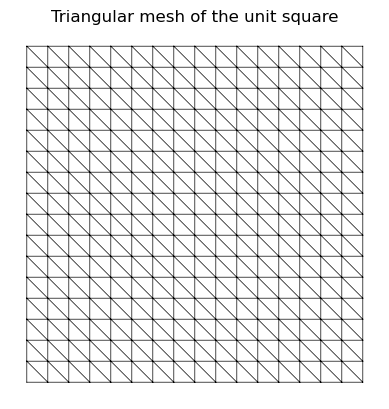

In [3]:
ax = mesh.draw()
ax.set_title("Triangular mesh of the unit square")
plt.show()

## Step 2: Define the finite element space

We choose **linear triangular elements** (`P1` elements).  
That means the solution is piecewise linear over each triangle.

In [4]:
element = ElementTriP1()
basis = Basis(mesh, element)

print("Number of global degrees of freedom:", basis.N)

Number of global degrees of freedom: 289


## Step 3: Write the weak form

For the Poisson problem

$$
-\nabla^2 u = 1,
$$

the weak form is:

$$
\int_\Omega \nabla u \cdot \nabla v \, d\Omega
=
\int_\Omega 1 \cdot v \, d\Omega
$$

for all test functions $v$.

In [5]:
@BilinearForm
def laplace(u, v, w):
    return dot(grad(u), grad(v))

@LinearForm
def rhs(v, w):
    return 1.0 * v

In [6]:
A = asm(laplace, basis)
b = asm(rhs, basis)

print("A shape:", A.shape)
print("b shape:", b.shape)

A shape: (289, 289)
b shape: (289,)


## Step 4: Apply Dirichlet boundary conditions

We want

$$
u=0 \quad \text{on the boundary}.
$$

In [7]:
boundary_dofs = basis.get_dofs().all()
print("Number of boundary dofs:", len(boundary_dofs))

AII, bI, xI, I = condense(A, b, D=boundary_dofs)
u = solve(AII, bI)

full_solution = xI.copy()
full_solution[I] = u

Number of boundary dofs: 64


## Step 5: Plot the solution

The result should look like a smooth bowl-shaped surface:
- zero at the boundary,
- positive inside,
- largest near the center.

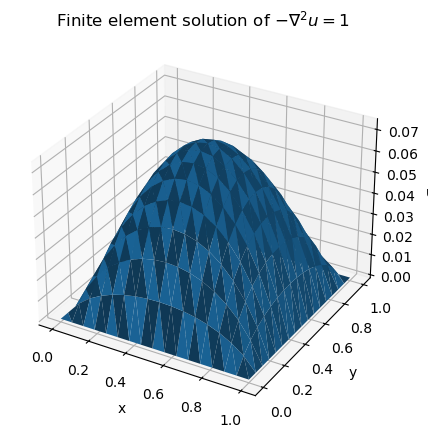

In [8]:
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection='3d')

triangles = mesh.t.T
x = mesh.p[0]
y = mesh.p[1]

ax.plot_trisurf(x, y, full_solution, triangles=triangles, linewidth=0.2, antialiased=True)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("u")
ax.set_title("Finite element solution of $-\\nabla^2 u = 1$")
plt.show()

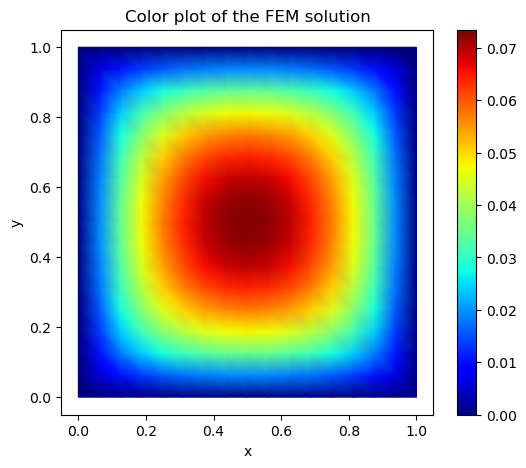

In [9]:
plt.figure(figsize=(6, 5))
ax = plt.gca()
mesh.plot(full_solution, ax=ax, shading='gouraud', colorbar=True)
ax.set_title("Color plot of the FEM solution")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.show()

## Step 6: Compare mesh refinements

We now solve the same problem with different mesh refinements.

In [10]:
def solve_poisson_refinement(nref):
    mesh = MeshTri().refined(nref)
    basis = Basis(mesh, ElementTriP1())
    A = asm(laplace, basis)
    b = asm(rhs, basis)
    D = basis.get_dofs().all()
    AII, bI, xI, I = condense(A, b, D=D)
    uI = solve(AII, bI)
    u = xI.copy()
    u[I] = uI
    return mesh, u

refinements = [2, 3, 4]
solutions = [solve_poisson_refinement(r) for r in refinements]

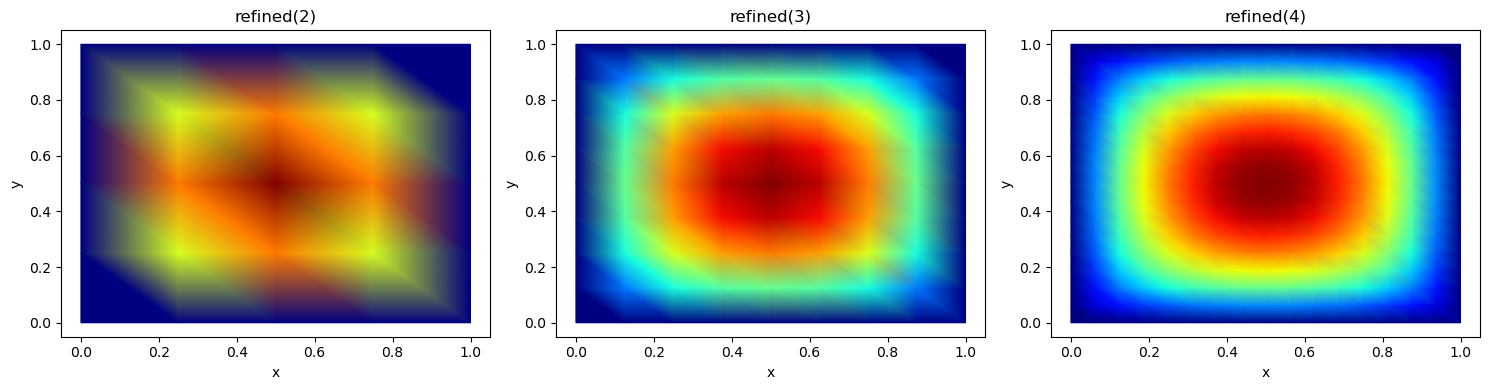

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (r, (mesh_r, u_r)) in zip(axes, zip(refinements, solutions)):
    mesh_r.plot(u_r, ax=ax, shading='gouraud', colorbar=False)
    ax.set_title(f"refined({r})")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.tight_layout()
plt.show()

## Discussion

What did the library do for us?

- It created the basis functions internally.
- It handled the assembly automatically.
- It gave us sparse matrices and efficient solvers.
- It let us focus on the weak form rather than on low-level indexing.

But the concepts are **exactly the same** as in the hand-built NumPy solver.

## Exercises

1. Change the right-hand side from $1$ to $10$.
2. Try fewer or more mesh refinements.
3. Replace the source by a function such as
   $$
   f(x,y)=2\pi^2\sin(\pi x)\sin(\pi y).
   $$
4. Try to guess where the maximum of the solution should occur.
5. Explain why the solution is zero on the edges.